<a href="https://colab.research.google.com/github/joyangelai/Colabs/blob/main/Cohort2_Linux_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning/Cleansing/Wrangling

## Data cleaning will cover the following
1. Checking the columns and changing mispelled to correct names
2. checking missing values
3. checking for duplicates
4. checking for outliers

In [ ]:
#Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(pd.__version__)

2.2.3


### 1. Loading the dataset and getting information

In [ ]:
#Reading the file: load diabetes.csv
data = pd.read_csv("diabetes.csv")

In [ ]:
#Checking top 5 columns
data.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [ ]:
#checking the last 5 columns
data.tail()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
1004,191,454316,M,55.0,NaN,62.0,6.8,5.3,2.0,1.0,3.5,0.9,30.1,Y
1005,192,454316,M,55.0,4.8,88.0,NaN,5.7,4.0,0.9,3.3,1.8,30.0,Y
1006,193,454316,M,62.0,6.3,82.0,6.7,5.3,2.0,1.0,3.5,NaN,30.1,Y
1007,194,454316,F,57.0,4.1,70.0,9.3,5.3,3.3,1.0,1.4,1.3,29.0,Y
1008,195,4543,f,55.0,4.1,34.0,13.9,5.4,1.6,1.6,3.1,0.7,33.0,Y


Observation: Data is uniform from top to bottom

In [ ]:
#checking the dataset shape
data.shape

(1009, 14)

In [ ]:
#checking the dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1009 non-null   int64  
 1   No_Pation  1009 non-null   int64  
 2   Gender     1009 non-null   object 
 3   AGE        1008 non-null   float64
 4   Urea       1008 non-null   float64
 5   Cr         1007 non-null   float64
 6   HbA1c      1006 non-null   float64
 7   Chol       1007 non-null   float64
 8   TG         1007 non-null   float64
 9   HDL        1008 non-null   float64
 10  LDL        1007 non-null   float64
 11  VLDL       1008 non-null   float64
 12  BMI        1009 non-null   float64
 13  CLASS      1009 non-null   object 
dtypes: float64(10), int64(2), object(2)
memory usage: 110.5+ KB


In [ ]:
#checking the info 2
data.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Columns: 14 entries, ID to CLASS
dtypes: float64(10), int64(2), object(2)
memory usage: 110.5+ KB


In [ ]:
#concise summary statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1009.0,339.161546,2.397382e+02,1.0,127.0,296.0,548.0,800.00
No_Pation,1009.0,271744.776016,3.365681e+06,123.0,24065.0,34399.0,45390.0,75435657.00
AGE,1008.0,53.620040,8.740975e+00,25.0,51.0,55.0,59.0,79.00
Urea,1008.0,5.131094,2.931136e+00,0.5,3.7,4.6,5.7,38.90
Cr,1007.0,68.973188,5.981330e+01,6.0,48.0,60.0,73.0,800.00
HbA1c,1006.0,8.284155,2.533576e+00,0.9,6.5,8.0,10.2,16.00
Chol,1007.0,4.863873,1.297326e+00,0.0,4.0,4.8,5.6,10.30
TG,1007.0,2.348769,1.397487e+00,0.3,1.5,2.0,2.9,13.80
HDL,1008.0,1.204216,6.581583e-01,0.2,0.9,1.1,1.3,9.90
LDL,1007.0,2.610119,1.116095e+00,0.3,1.8,2.5,3.3,9.90


In [ ]:
#Describe categorical features
data.describe(include="O")

,Gender,CLASS
count,1009,1009
unique,3,5
top,M,Y
freq,570,840


In [ ]:
#Create a dataframe copy to be used in data cleaning using copy() method
data_1 = data.copy(deep=True)
data_1.head(2)

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N


In [ ]:
# Here, I have to verify that data_1 is independent of data just to ensure the above cell worked
data_1.iloc[0, 0] = 99999999
data_1.head(2)

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,99999999,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N


In [ ]:
# Now to revert the changes I made to data_1 so that we can continue with manipulation
data_1.iloc[0,0] = data.iloc[0,0]
data_1.head(2)

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N


In [ ]:
#check unique value for one variable
data["Gender"].unique()

array(['F', 'M', 'f'], dtype=object)

In [ ]:
# check for unique values in each column at once using for loop
for column in data_1:
    unique_val = data_1[column].unique()
    print(f"column_name:{column} : {unique_val}, \n")


column_name:ID : [502 735 420 680 504 634 721 421 670 759 636 788  82 132 402 566 596 676
 729 742  64  97 126 390 458 470 494 564 696 106 138 315 650 678 699 703
 708 719 740 741 746 794 219 255 450 626 664 704 799 210 237 318 620 640
 668 701 174 276 345 482 630 789 348   7   9  10  42  47  71  72  83  88
  89  96  98  99 102 134 137 139 141 143 144 145 147 149 150 153 154 157
 161 165 166 171 180 181 182 186 190 197 435 472  85 710 429 702   4 189
 201 285 393 468 492 496 498 684 700 716 366 399 490 500 672 690 718 264
 464 466 686 688  16 705 709  19 123 476 682 706 754  68 342 712 715  12
  20  41  60  79  81 133 135 146 152 178  18  24 675  39 474 648  48 656
  57 658  69 662 714  87 231 505 654  61 127 228 674 744  58 108 198 357
 588 666 698 753 110 113 119 122 452 652 660 673 162 168 580 694 790 140
 375 426 453 534 612 692 717 725 777  67 109 351 552 685 750  31 129 173
 176 179 183 185 195 316 646 187 188 191 194 200 203 411 520 622 758 206
 600  76  86 209 212 215 218 221 2

### 2. Data Cleaning


#### 2.1. Checking the colunms and dealing with mispelled columns

In [ ]:
#check the colunms use columns attribute
data_1.columns

Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')

In [ ]:
#changing no_pation column, use rename method e.g df.rename(columns = {'old col name': 'new coln name'}, inplace = True )
data_1.rename(columns = {"No_Pation" : "Patient No"}, inplace=True)
data_1.columns

Index(['ID', 'Patient No', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol',
       'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')

In [ ]:
#Change columns name to lower case for unifromity# use .lower(), eg df.columns = df.columns.str.lower()
data_1.columns = data_1.columns.str.lower()
data_1.columns  # confirming the changes

Index(['id', 'patient no', 'gender', 'age', 'urea', 'cr', 'hba1c', 'chol',
       'tg', 'hdl', 'ldl', 'vldl', 'bmi', 'class'],
      dtype='object')

In [ ]:
#Removing the white space if any, use .replace() e.g df.columns = df.columns.str.replace(' ', '')
data_1.columns = data_1.columns.str.replace(" ","")
data_1.columns

Index(['id', 'patientno', 'gender', 'age', 'urea', 'cr', 'hba1c', 'chol', 'tg',
       'hdl', 'ldl', 'vldl', 'bmi', 'class'],
      dtype='object')

In [ ]:
#Removing whitespace before or after the variable name
data_1['class']= data_1['class'].str.strip()

In [ ]:
#we can combine the 2 argument into one code
#df1.columns = df1.columns.str.lower().replace(' ', '_')
"""data_1.columns =data_1.columns.str.lower().replace(' ','_')"""

In [ ]:
#Drop unnessary columns
#a. del df['col name'] # you can also used drop method: df.drop(columns = 'col_name', axis=1, inplace=True)

# when dropping one variable
del data_1["id"]
data_1.columns

#using drop method
#data_1.columns = data_1.drop(columns = "id", axis = 1, inplace=True)
#data_1.columns


Index(['patient_no', 'gender', 'age', 'urea', 'cr', 'hba1c', 'chol', 'tg',
       'hdl', 'ldl', 'vldl', 'bmi', 'class'],
      dtype='object')

### 2.2 Checking the missing values and dealing with them

In [ ]:
#check the missing values, you can either use isna or isnull()
data_1.isnull().sum() #can be converted into %

id           0
patientno    0
gender       0
age          1
urea         1
cr           2
hba1c        3
chol         2
tg           2
hdl          1
ldl          2
vldl         1
bmi          0
class        0
dtype: int64

In [ ]:
data_1.isnull().sum().sum()

np.int64(15)

In [ ]:
data_1.isnull().sum().any()

np.True_

In [ ]:
#a. imputing "hba1c " variable using the mean
#Get the mean  e.g mean_values = df.coln.mean()
mean_val = data_1['hba1c'].mean()
mean_val
#fill up the missing value, use fillna e.g df['col'].fillna(mean_values, inplace=True)  ---> this throws a warning
# new format --> df['col'] = df['col'].fillna
data_1['hba1c'] = data_1['hba1c'].fillna(mean_val)  # Correct approach
data_1['hba1c'].head(3)

0    4.9
1    4.9
2    4.9
Name: hba1c, dtype: float64

In [ ]:
data_1.isnull().sum()

id           0
patientno    0
gender       0
age          1
urea         1
cr           2
hba1c        0
chol         2
tg           2
hdl          1
ldl          2
vldl         1
bmi          0
class        0
dtype: int64

In [ ]:
#b another way of doing the same thing as a bove e.g df['col'].fillna(df['col'].mean(), inplace=True)
data_1['hba1c'] = data_1['hba1c'].fillna(data_1['hba1c'].mean())
data_1.head(3)

,patient_no,gender,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,class
0,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N


In [ ]:
# imputing null values using another method
agemean = data_1['age'].mean()
data_1.fillna({'age':agemean}, inplace=True)
data_1.isnull().sum()

id           0
patientno    0
gender       0
age          0
urea         1
cr           2
hba1c        0
chol         2
tg           2
hdl          1
ldl          2
vldl         1
bmi          0
class        0
dtype: int64

In [ ]:
#c Imputing using the median" replace mean with median
data_1['hba1c']= data_1['hba1c'].fillna(data_1['hba1c'].median())
data_1['hba1c']

0        4.900000
1        4.900000
2        4.900000
3        4.900000
4        4.900000
          ...    
1004     6.800000
1005     8.284155
1006     6.700000
1007     9.300000
1008    13.900000
Name: hba1c, Length: 1009, dtype: float64

In [ ]:
#d. how to impute using the mode
#coln_mode = df.colname.mode()[0]
mode_class = data_1["class"].mode()[0]
mode_class
# impute with the mode
#df['col'].fillna(col_mode, inplace=True) # use bfill for backword fill, and ffill for forward fill

'Y'

Observations:

The mode of a dataset can have multiple values. When we call `mode()` on a Pandas dataframe, it returns a Series object containing all the modal values. To access the first modal value, we use the `[0]` index.

For example, if the mode of the `gender` column in the `df1` dataframe is both `'Female'` and `'Male'`, then `df1.gender.mode()` will return a Series object containing both values. To access the first modal value, which is `'Female'`, we use `df1.gender.mode()[0]`.

Using `[0]` ensures that we are only using the first modal value for imputation, rather than all the modal values. This is important because using multiple values for imputation can introduce bias into the data.

In [ ]:
data_1.isnull().sum()

id           0
patientno    0
gender       0
age          0
urea         1
cr           2
hba1c        0
chol         2
tg           2
hdl          1
ldl          2
vldl         1
bmi          0
class        0
dtype: int64

In [ ]:
#e. Fill missing values with specific values e.g 0
#df['col'].fillna(0, inplace=True)
data_1['chol'].fillna(0)

0       4.2
1       3.7
2       4.2
3       4.2
4       4.9
       ... 
1004    5.3
1005    5.7
1006    5.3
1007    5.3
1008    5.4
Name: chol, Length: 1009, dtype: float64

In [ ]:
#f.Fill missing values in the categorical columns with specific values
#df['col'].fillna('unknown', inplace=True)


In [ ]:
#dropping the missing values# we drop when we just have few missing values using dropna
data_1.dropna(inplace=True)
data_1.isnull().sum()

id           0
patientno    0
gender       0
age          0
urea         0
cr           0
hba1c        0
chol         0
tg           0
hdl          0
ldl          0
vldl         0
bmi          0
class        0
dtype: int64

In [ ]:
#check the null values using isna()
data_1.isna().sum()

id           0
patientno    0
gender       0
age          0
urea         0
cr           0
hba1c        0
chol         0
tg           0
hdl          0
ldl          0
vldl         0
bmi          0
class        0
dtype: int64

In [ ]:
#Replacing values in the class column
data_1.groupby('gender')['gender'].count()

gender
F    432
M    563
f      2
Name: gender, dtype: int64

In [ ]:
#check unique in class variable
data_1["class"].unique()   #there's a problem if you see an empty array

array(['N', 'N ', 'P', 'Y', 'Y '], dtype=object)

In [ ]:
# replace values in class, and gender coln df['coln'] = df['coln'].str.replace('N ','N')
# Fix N value from class column
data_1["class"] = data_1["class"].str.replace("N ", "N")

# fix Y value from class column
data_1['class'] = data_1['class'].str.replace('Y ', "Y")

# Key note: --> the classes were of four types because of whitespace of N and Y
data_1["class"].unique()

array(['N', 'P', 'Y'], dtype=object)

In [ ]:
#check unique again  --> you see it works fine now
data_1['class'].unique()

array(['N', 'P', 'Y'], dtype=object)

In [ ]:
data_1.head()

,patient_no,gender,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,class
0,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [ ]:
#check count again  df.groupby('class')['class'].count()
data_1.groupby('class')['class'].count()

class
N    103
P     53
Y    842
Name: class, dtype: int64

In [ ]:
#do the same for gender
data_1['gender'].unique()

array(['F', 'M', 'f'], dtype=object)

In [ ]:
#replace values in gender
data_1['gender'] = data_1['gender'].str.replace('f', "F")
data_1['gender'].unique()

array(['F', 'M'], dtype=object)

In [ ]:
data_1.groupby('gender')['gender'].count()

gender
F    435
M    563
Name: gender, dtype: int64

### 2.3 Checking for duplicate


In [ ]:
#check duplicates use duplcated()
data_1.duplicated().sum()

np.int64(3)

In [ ]:
#drop the duplicates
data_1.drop_duplicates(inplace=True)

#checking on whether duplicates were dropped
data_1.duplicated().sum()

np.int64(0)

### 2.4 Checking for outliers


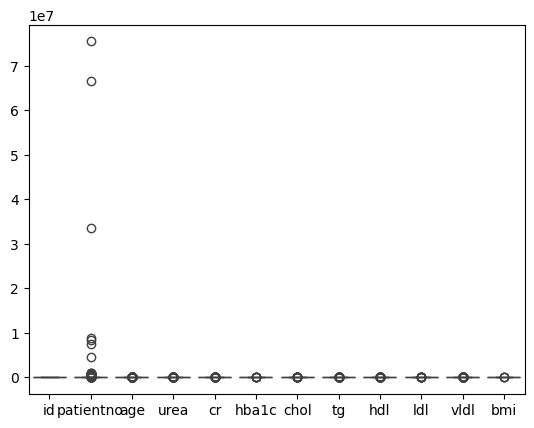

In [ ]:
#checking for outlier, use boxplot on cr coln
sns.boxplot(data_1);

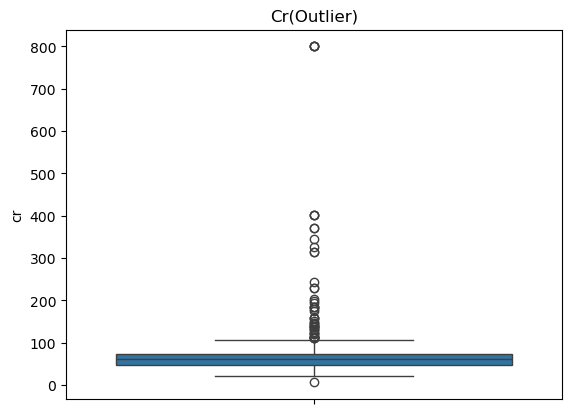

In [ ]:
#check outlier for cr
sns.boxplot(y=data_1['cr'])
plt.title("Cr(Outlier)");

In [ ]:
#concise summary
data_1.describe().T

,count,mean,std,min,25%,50%,75%,max
id,995.0,341.414070,2.406356e+02,1.0,125.00,303.0,551.5,800.00
patientno,995.0,272115.145729,3.389208e+06,123.0,24063.50,34394.0,45382.5,75435657.00
age,995.0,53.579518,8.727614e+00,25.0,51.00,55.0,59.0,79.00
urea,995.0,5.123762,2.942156e+00,0.5,3.68,4.6,5.7,38.90
cr,995.0,68.760804,6.003320e+01,6.0,48.00,60.0,73.0,800.00
hba1c,995.0,8.282123,2.535343e+00,0.9,6.50,8.0,10.2,16.00
chol,995.0,4.861628,1.299955e+00,0.0,4.00,4.8,5.6,10.30
tg,995.0,2.347347,1.399616e+00,0.3,1.50,2.0,2.9,13.80
hdl,995.0,1.205377,6.618246e-01,0.2,0.90,1.1,1.3,9.90
ldl,995.0,2.611548,1.116720e+00,0.3,1.80,2.5,3.3,9.90


In [ ]:
#Remove the outlier using the maximum quantile in cr column

#a. Get the max interquantile at 0.995
max_ir = data_1['cr'].quantile(0.995)
max_ir

np.float64(401.0)

In [ ]:
#check the values under outliers
#df[df["cr"] > max_ir
data_1[data_1['cr'] > max_ir]

,patient_no,gender,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,class
273,34325,M,58.0,20.8,800.0,9.1,6.6,2.9,1.1,4.3,1.3,33.0,Y
283,24060,M,58.0,20.8,800.0,9.1,6.6,2.9,1.1,4.3,1.3,33.0,Y
846,34325,M,56.0,20.8,800.0,9.0,4.6,2.0,1.2,2.5,0.9,35.0,Y
860,51623,M,60.0,20.8,800.0,9.0,2.3,1.1,0.9,0.9,0.5,33.0,Y


In [ ]:
# getting the min interquantile at 0.0
min_ir = data_1['cr'].quantile(0.0)

# checking the values over the outlier
data_1[data_1['cr'] < min_ir]    # --> best practices typa shii. Just to check wrong data entry. This isnt a must tho!

,id,patientno,gender,age,urea,cr,hba1c,chol,tg,hdl,ldl,vldl,bmi,class


In [ ]:
#Remove the outlier by assigning the value to a new DataFrame
#dfnew = df[df["cr"] < max_ir]
dfnew = data_1[data_1['cr'] < max_ir]

The above cell implies that the outliers have been "removed" by isolation.
'dfnew' variable contains data that is normal, (without outliers) so that they can be used for visualization.
Since this is medical data, such outliers can communicate a lot and can be of beneficiary, so this is best practice to just isolate it and not get rid of it by creating a new DataFrame as the one that has been done above.

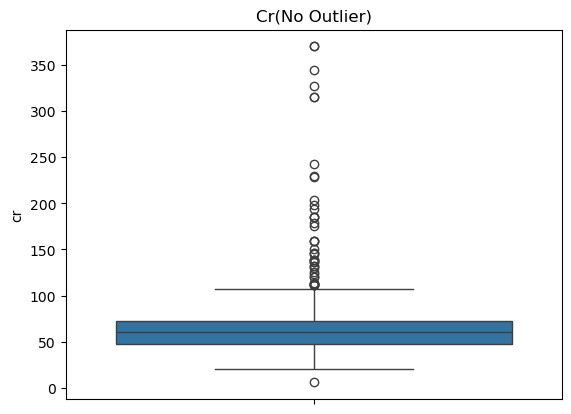

In [ ]:
#confirm removal of outlier
sns.boxplot(y = dfnew['cr'])
plt.title('Cr(No Outlier)');

The outlier has been removed

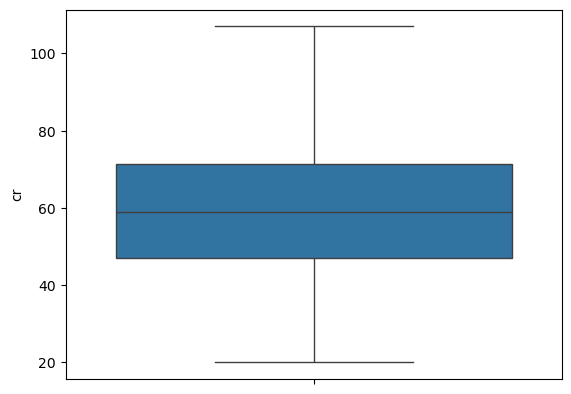

In [ ]:
#b. similary we can use iqr to remove the outliers

# Calculate the interquartile range (IQR)
#q1 = df['cr'].quantile(0.25)
q1 =data_1['cr'].quantile(0.25)
q3 = data_1['cr'].quantile(0.75)
iqr = q3 - q1
#q3 = df['cr'].quantile(0.75)
#iqr = q3 - q1

# Define the lower and upper bounds for outliers
#lower_bound = q1 - 1.5 * iqr
#upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
# Filter the data to remove outliers
#f2 = df1[(df['cr'] >= lower_bound) & (df['cr'] <= upper_bound)]

f2 = data_1[(data_1['cr'] >= lower_bound) & (data_1['cr'] <= upper_bound)]
f2
# Check the boxplot again
sns.boxplot(y= f2['cr']);